# 上海单城一步联合预测与 TM 因果图实验

这个 notebook 复用上海一步联合预测主线，但把图上的边权计算切到 `transport map` 概率密度估计。

- pairwise 图使用 `O3 -> O3` 的 `EI^tm`
- 条件协同图使用 `O3 + PM2.5 -> O3` 的 `Syn^tm`
- `EI^tm` / `Syn^tm` 的定义与 `exp/tm_vs_nis.ipynb` 中的对比实验保持一致
- 这一版只保留两张图，不再展示 `Syn / EI_joint` 比例图


In [1]:
from __future__ import annotations

from dataclasses import replace

import os
import sys
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "yrd").is_dir() and (candidate / "data").is_dir():
        ROOT = candidate
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Could not locate project root containing yrd/ and data/")

from IPython.display import Image, display

from yrd.shanghai_notebook import (
    build_default_shanghai_one_step_config,
    build_prediction_tables,
    build_run_tag,
    build_transport_map_global_causal_summary,
    compute_station_causal_graph_results,
    configure_notebook_runtime,
    prepare_shanghai_one_step_bundle,
    run_or_load_one_step_predictions,
)

configure_notebook_runtime()


In [6]:
# 是否启用 notebook 烟雾测试模式；开启后会把采样数和显示边数缩到很小，便于快速自检。
NOTEBOOK_TEST_MODE = os.getenv("YRD_NOTEBOOK_TEST_MODE", "0") == "1"
# 是否强制重新训练一步预测模型；通常保持 False，直接复用已有 checkpoint。
FORCE_RETRAIN = False
# 是否强制重算 TM 因果边；False 时若缓存参数一致会直接复用缓存结果。
FORCE_RECOMPUTE_COUPLING = False
# 因果边估计方法；当前 notebook 主要使用 transport map，因此保持为 "tm"。
CAUSAL_GRAPH_METHOD = "tm"

# === TM 因果图可调参数：直接改这里 ===
# 当前采用的 L 配置名，仅用于在结论里标记来源，真正生效的是下面这个逐变量字典。
CAUSAL_GRAPH_L_PROFILE_NAME = "L_profile_pollutant_x1.2"
# 每个输入变量各自的采样半宽 L_v，单位是原变量标准化前的 train-q99 尺度。
CAUSAL_GRAPH_L_BY_VARIABLE_STD_Q99 = {
    "O3": 7.716,      # O3 的干预采样半宽。
    "PM2.5": 9.0,     # PM2.5 的干预采样半宽。
    "t2m": 4.25,      # 2 米气温的干预采样半宽。
    "d2m": 4.56,      # 2 米露点温度的干预采样半宽。
    "sp": 4.30,       # 地表气压的干预采样半宽。
    "tp": 8.87,       # 总降水的干预采样半宽。
    "blh": 5.99,      # 边界层高度的干预采样半宽。
    "msdwswrf": 5.93, # 向下短波辐射的干预采样半宽。
    "u100": 5.37,     # 100 米 U 风分量的干预采样半宽。
    "v100": 4.72,     # 100 米 V 风分量的干预采样半宽。
}
# 这些变量在原始量纲下不应小于 0，因此采样时会施加下界裁剪。
CAUSAL_GRAPH_NONNEGATIVE_VARIABLES = ("O3", "PM2.5", "t2m", "d2m", "sp", "tp", "blh", "msdwswrf")
# TM Monte Carlo / 合成干预样本数 M；越大越稳定，但耗时越高。
CAUSAL_GRAPH_COUPLING_SAMPLE_COUNT = 8192
# 在“候选显示边”基础上最终保留多少比例用于画图；1 表示全部保留，<1 表示只画最强的一部分。
CAUSAL_GRAPH_EDGE_KEEP_FRACTION = 1
# 绘图箭头大小参数；只影响可视化，不影响边权估计。
CAUSAL_GRAPH_ARROW_MUTATION_SCALE = 24.0
# 绘图箭头离节点终点的收缩距离；只影响可视化，不影响边权估计。
CAUSAL_GRAPH_ARROW_SHRINK_TARGET = 6.0
# 实际生效的采样数；测试模式下自动降到 4，加快 notebook 自检。
EFFECTIVE_CAUSAL_GRAPH_COUPLING_SAMPLE_COUNT = 4 if NOTEBOOK_TEST_MODE else CAUSAL_GRAPH_COUPLING_SAMPLE_COUNT

default_cfg = build_default_shanghai_one_step_config(ROOT, test_mode=NOTEBOOK_TEST_MODE)
cfg = replace(
    default_cfg,
    causal_graph_box_size_by_variable=CAUSAL_GRAPH_L_BY_VARIABLE_STD_Q99,
    causal_graph_nonnegative_variables=CAUSAL_GRAPH_NONNEGATIVE_VARIABLES,
)
bundle = prepare_shanghai_one_step_bundle(
    cfg=cfg,
    city_en="shanghai",
    run_tag=f"{build_run_tag(test_mode=NOTEBOOK_TEST_MODE)}_tm_causal_graph",
    use_smoke=NOTEBOOK_TEST_MODE,
    coupling_sample_count=EFFECTIVE_CAUSAL_GRAPH_COUPLING_SAMPLE_COUNT,
    graph_edges_per_target=1 if NOTEBOOK_TEST_MODE else 50,  # 每个目标站点最多显示多少条 conditional synergy / hyperedge 候选边。
    causal_graph_edge_keep_fraction=CAUSAL_GRAPH_EDGE_KEEP_FRACTION,
    causal_graph_arrow_mutation_scale=CAUSAL_GRAPH_ARROW_MUTATION_SCALE,
    causal_graph_arrow_shrink_target=CAUSAL_GRAPH_ARROW_SHRINK_TARGET,
    causal_graph_variable="O3",
)

artifact_paths = bundle["artifact_paths"]
run_context = bundle["run_context"]
run_context


{'run_tag': 'shanghai_one_step_o3_station_graph_tm_causal_graph',
 'city_en': 'shanghai',
 'test_mode': False,
 'use_smoke': False,
 'sample_mode': 'one_step',
 'data_resolution_hours': 1,
 'history_hours': 1,
 'horizons': [1],
 'epochs': 12,
 'batch_size': 64,
 'hidden_dim': 96,
 'model_name': 'resmlp',
 'num_layers': 3,
 'dropout': 0.05,
 'norm_type': 'layernorm',
 'activation': 'silu',
 'station_count': 19,
 'input_shape': [19, 10],
 'effective_input_dim': 190,
 'full_effective_input_dim': 190,
 'train_samples': 52607,
 'val_samples': 8760,
 'test_samples': 8760,
 'coupling_sample_count': 8192,
 'graph_edges_per_target': 50,
 'causal_graph_variable': 'O3',
 'causal_graph_sampling_mode': 'uniform_box_centered_at_train_mean',
 'causal_graph_center_source': 'train_input_mean',
 'causal_graph_sampling_seed': 0,
 'causal_graph_edge_keep_fraction': 1.0,
 'causal_graph_arrow_mutation_scale': 24.0,
 'causal_graph_arrow_shrink_target': 6.0,
 'requested_causal_graph_box_size_by_variable': {'O

In [3]:
predictions = run_or_load_one_step_predictions(bundle, force_retrain=FORCE_RETRAIN)
metrics_bundle = build_prediction_tables(bundle, predictions)
metrics_frame = metrics_bundle["metrics_frame"]
metrics_overall_df = metrics_bundle["metrics_overall_df"]
metrics_pollutant_df = metrics_bundle["metrics_pollutant_df"]
station_metrics_df = metrics_bundle["station_metrics_df"]

metrics_overall_df, metrics_pollutant_df.head(), station_metrics_df.head()


(                 model horizon    scope       rmse       mae      corr
 0  PersistenceBaseline      1h  overall  10.087296  6.239973  0.967226
 1      JointStationMLP      1h  overall   8.588598  5.719339  0.975967,
                  model horizon  scope       rmse       mae      corr
 0  PersistenceBaseline      1h     O3  12.976127  8.738608  0.951490
 1  PersistenceBaseline      1h  PM2.5   5.926822  3.741336  0.964041
 2      JointStationMLP      1h     O3  10.589280  7.494790  0.967162
 3      JointStationMLP      1h  PM2.5   5.949386  3.943890  0.963321,
                  model horizon station_id       rmse       mae      corr
 0  PersistenceBaseline      1h      1141A   9.903348  6.331792  0.971078
 1  PersistenceBaseline      1h      1142A   9.824844  6.192180  0.966468
 2  PersistenceBaseline      1h      1143A   9.849519  6.354338  0.966889
 3  PersistenceBaseline      1h      1144A   9.947832  6.210731  0.968841
 4  PersistenceBaseline      1h      1145A  10.427306  6.32220

## TM 因果图

这一节不再从局部 Jacobian 直接套 `nis` 闭式公式，而是先在统一的均匀干预盒里生成经验样本，再用 `transport map` 概率密度估计互信息。

- pairwise 图：对每个源站点 `i`，只取当前时刻 `O3_i`，对每个目标站点 `j`，取下一小时 `O3_j`
- 条件协同图：对每个源站点 `i`，取当前时刻 `[O3_i, PM2.5_i]`，目标仍是下一小时 `O3_j`
- 因此，这里的两张图分别对应 `O3 -> O3` 和 `O3 + PM2.5 -> O3`


### 图上边权的数学定义

记第 `m` 个合成样本为
$$
\mathbf{x}^{(m)} \in \mathbb{R}^{S \times F}, \qquad m = 1, \dots, M,
$$
其中 `S` 是站点数，`F` 是每个站点的污染物特征数。这个 notebook 在训练输入均值附近的统一盒子内采样得到 `M` 个当前时刻样本，再把它们送入一步预测器，得到下一小时 `O3` 预测
$$
\hat{\mathbf{y}}^{(m)} = f\bigl(\mathbf{x}^{(m)}\bigr), \qquad \hat{\mathbf{y}}^{(m)} \in \mathbb{R}^{S}.
$$

对任意源变量块 `\mathbf{u}` 和目标变量 `\mathbf{v}`，TM 版本先用经验样本拟合一个仿射下三角 transport-map 风格密度模型，并据此估计互信息
$$
I^{\mathrm{tm}}(\mathbf{u}; \mathbf{v})
= \frac{1}{M} \sum_{m=1}^{M}
\left[
\log \hat p_{\mathrm{tm}}\bigl(\mathbf{u}^{(m)}, \mathbf{v}^{(m)}\bigr)
- \log \hat p_{\mathrm{tm}}\bigl(\mathbf{u}^{(m)}\bigr)
- \log \hat p_{\mathrm{tm}}\bigl(\mathbf{v}^{(m)}\bigr)
\right]
- b(d_u, d_v, M),
$$
其中 `\hat p_{\mathrm{tm}}` 是当前实现里由样本均值与协方差拟合出的仿射高斯 transport-map 密度，`b(d_u, d_v, M)` 是针对 `\log \det` 有限样本偏差的解析修正项。

1. `O3 -> O3` pairwise 图

对源站点 `i` 和目标站点 `j`，定义
$$
X_i := O3_i^{\mathrm{now}}, \qquad Y_j := \widehat{O3}_j^{\mathrm{next}}.
$$
则 `i \to j` 的 pairwise 边权为
$$
w_{i \to j}^{\mathrm{pair}}
= EI_{i \to j}^{\mathrm{tm}}
= I^{\mathrm{tm}}(X_i; Y_j).
$$
在当前实现里，表格中的 `mean` 就是这个量；图上只显示跨站且 `mean > 0` 的边，而站点自环 `i \to i` 不再画成回环，而是改用节点颜色表示其大小与符号。

2. `O3 + PM2.5 -> O3` conditional synergy 图

对同一源站点 `i`，记
$$
X_i^{(O3)} := O3_i^{\mathrm{now}}, \qquad X_i^{(PM)} := PM2.5_i^{\mathrm{now}}, \qquad Y_j := \widehat{O3}_j^{\mathrm{next}}.
$$
则联合输入对目标的 TM 联合信息量为
$$
EI_{i \to j}^{\mathrm{joint}, \mathrm{tm}}
= I^{\mathrm{tm}}\!\left(
\begin{bmatrix}
X_i^{(O3)} \\
X_i^{(PM)}
\end{bmatrix};
Y_j
\right),
$$
两个单变量项分别为
$$
EI_{i \to j}^{O3, \mathrm{tm}} = I^{\mathrm{tm}}(X_i^{(O3)}; Y_j),
\qquad
EI_{i \to j}^{PM, \mathrm{tm}} = I^{\mathrm{tm}}(X_i^{(PM)}; Y_j).
$$
因此，条件协同图中的边权定义为
$$
w_{i \to j}^{\mathrm{syn}}
= Syn_{i \to j}^{\mathrm{tm}}
= EI_{i \to j}^{\mathrm{joint}, \mathrm{tm}}
- EI_{i \to j}^{O3, \mathrm{tm}}
- EI_{i \to j}^{PM, \mathrm{tm}}.
$$
若 `w_{i \to j}^{\mathrm{syn}} > 0`，说明把 `O3_i` 与 `PM2.5_i` 一起看时，对预测 `O3_j` 的信息增益超过二者单独贡献之和。当前 notebook 的合成输入来自统一盒中的源端独立干预，因此理想化真值下不应再由源端共因带来冗余；如果估计结果出现负的 `EI^\mathrm{tm}` 或 `Syn^\mathrm{tm}`，更应优先解读为仿射 TM 密度拟合与有限样本估计造成的数值伪影，并通过增大 `M` 来检查其是否收敛回非负区域。

3. 为什么代码里还有 `mean`、`std`、`median`

虽然 `tm` 互信息本身已经是基于全部合成样本的一次全局估计，这套 notebook 仍统一走“按目标站点汇总成边表”的接口，因此最终边表保留了
$$
\mathrm{mean}, \quad \mathrm{std}, \quad \mathrm{median}.
$$
对当前 `tm` 实现来说，每条边通常只对应一次全局估计，因此 `mean` 就是实际用于解释和排序的边权，`std` 常常为 `0`。

4. 图上粗细和透明度不是新的边权

绘图时还会把保留下来的边做一个相对强度归一化：若某类图中保留边集合为 `\mathcal{E}`，则对任意边 `e \in \mathcal{E}` 计算
$$
s_e = \frac{w_e}{\max_{e' \in \mathcal{E}} w_{e'}}, \qquad 0 \le s_e \le 1,
$$
然后再把 `s_e` 映射成线宽和透明度。因此，图上真正的“边权”仍然是表格里的 `mean`；线宽与透明度只是为了可视化强弱差异，不是额外定义的因果量。

5. 当前 notebook 的展示筛选

- pairwise 图先保留所有跨站且 `mean > 0` 的边，再按 `mean` 从大到小取前 `keep_fraction`
- conditional synergy 图先对每个目标站点 `j` 保留 `graph_edges_per_target` 条最强正协同跨站边，再按全局 `keep_fraction` 做第二次截断

所以图上看到的是“筛选后的显示边”，而不是所有候选边的全集。


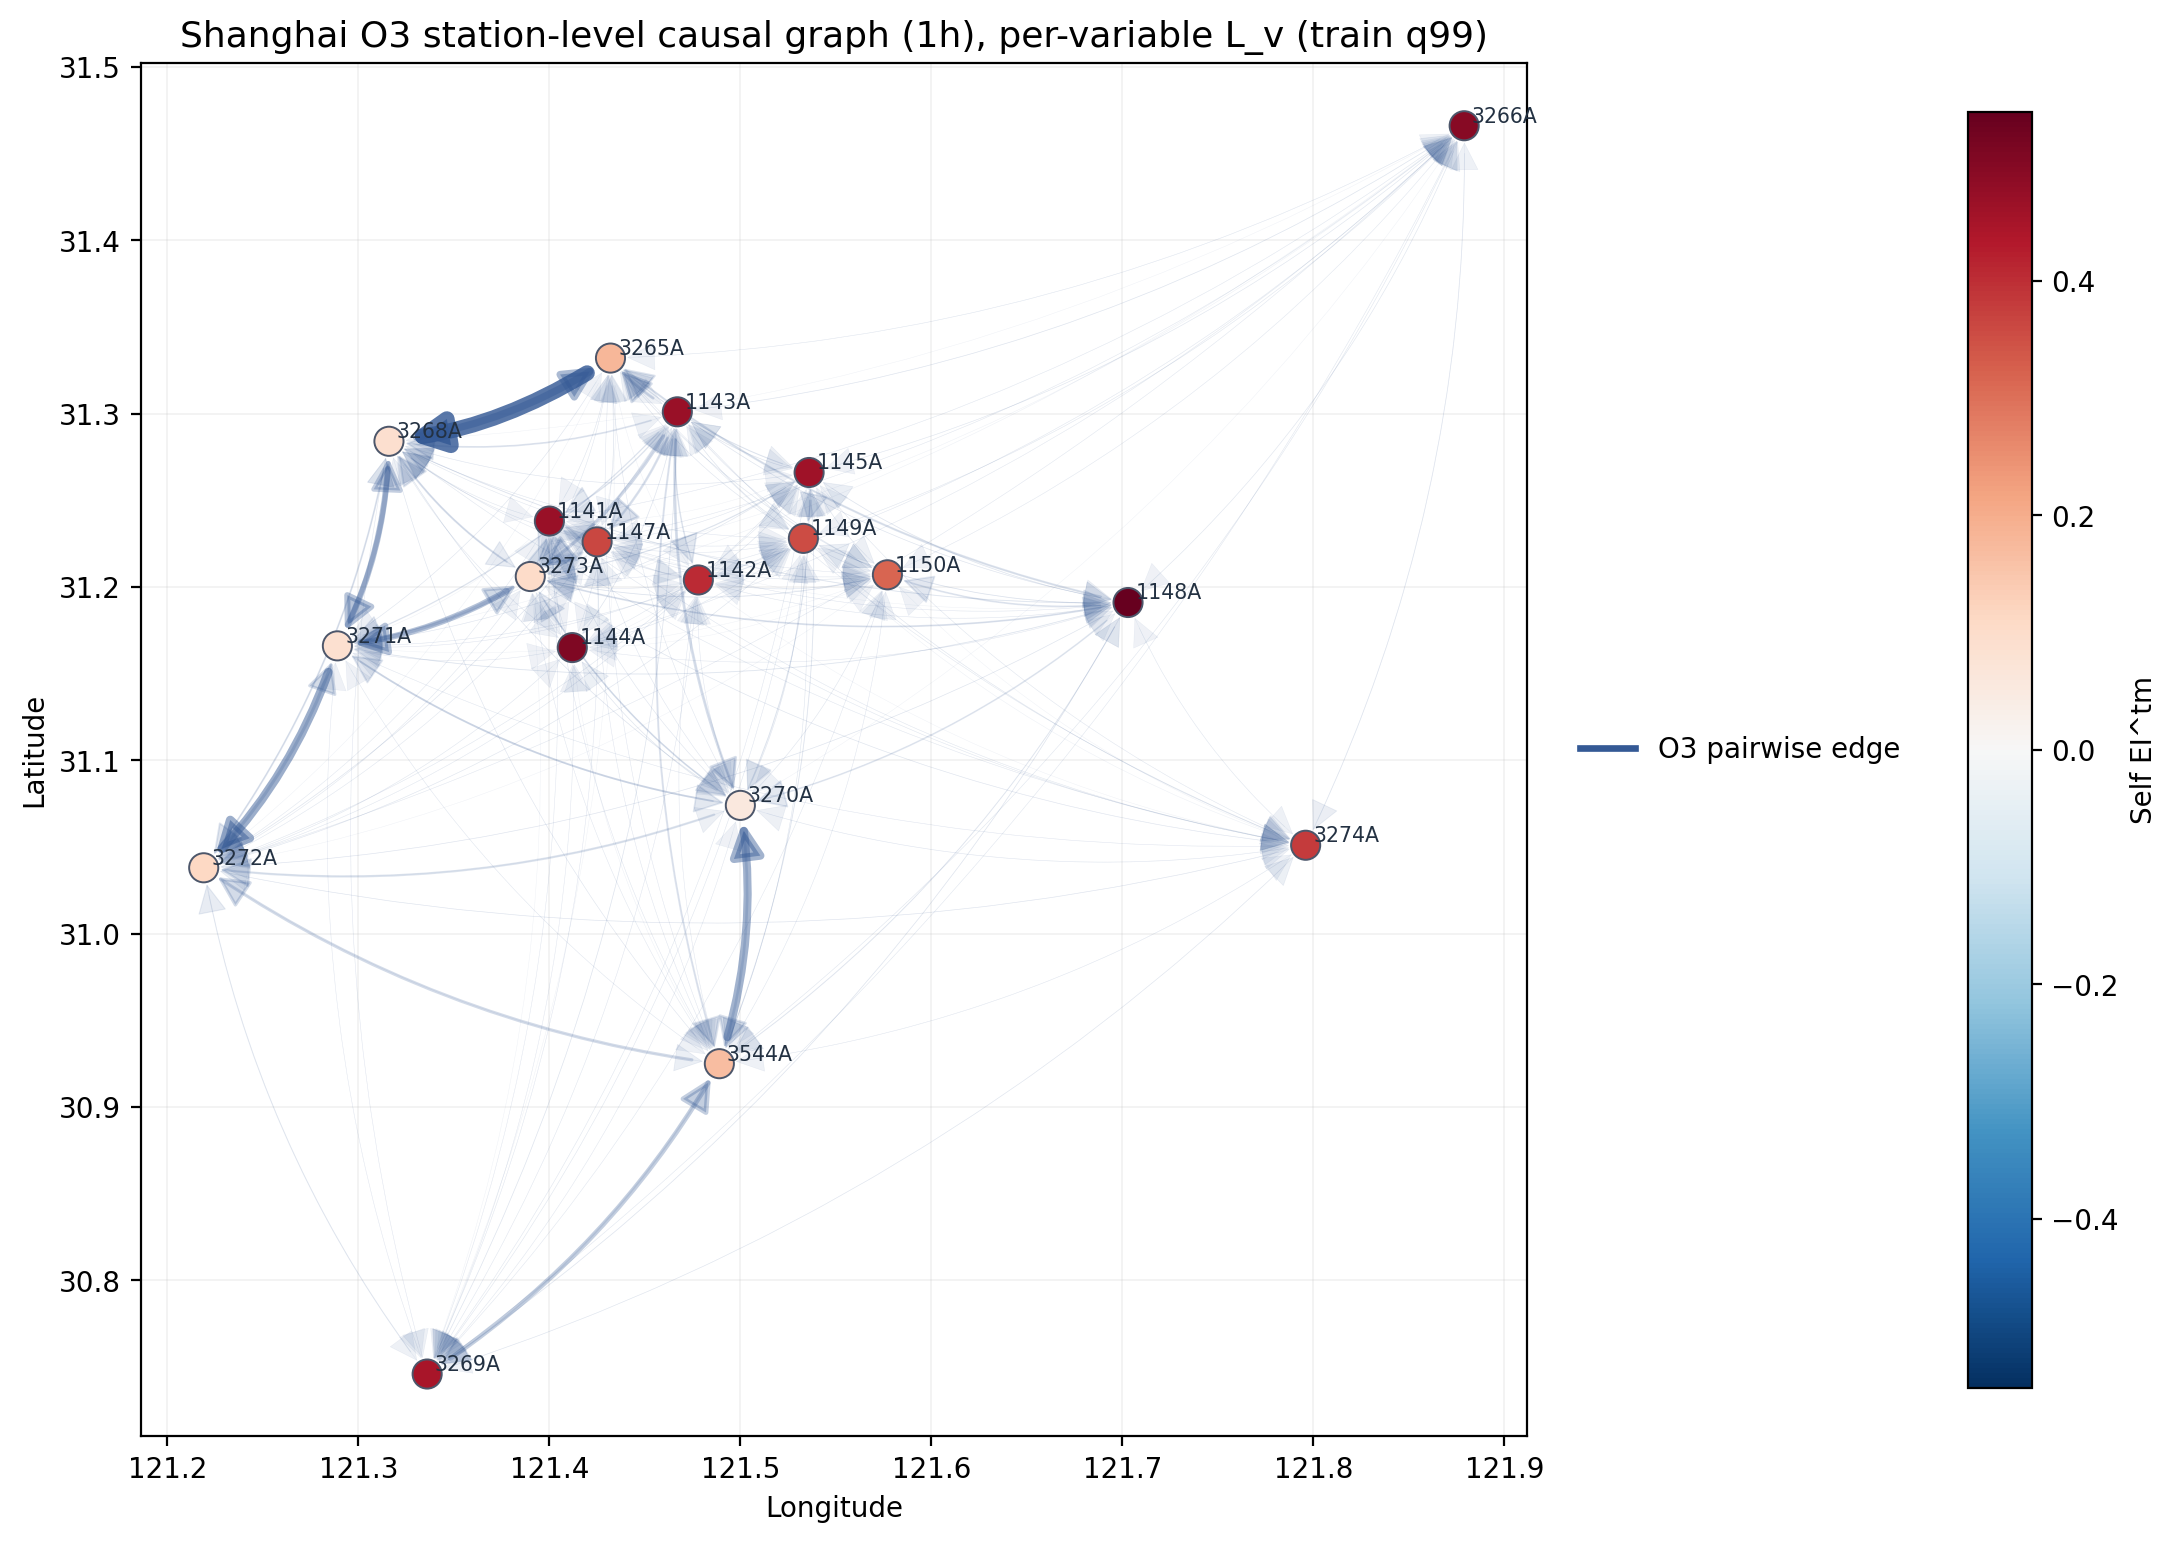

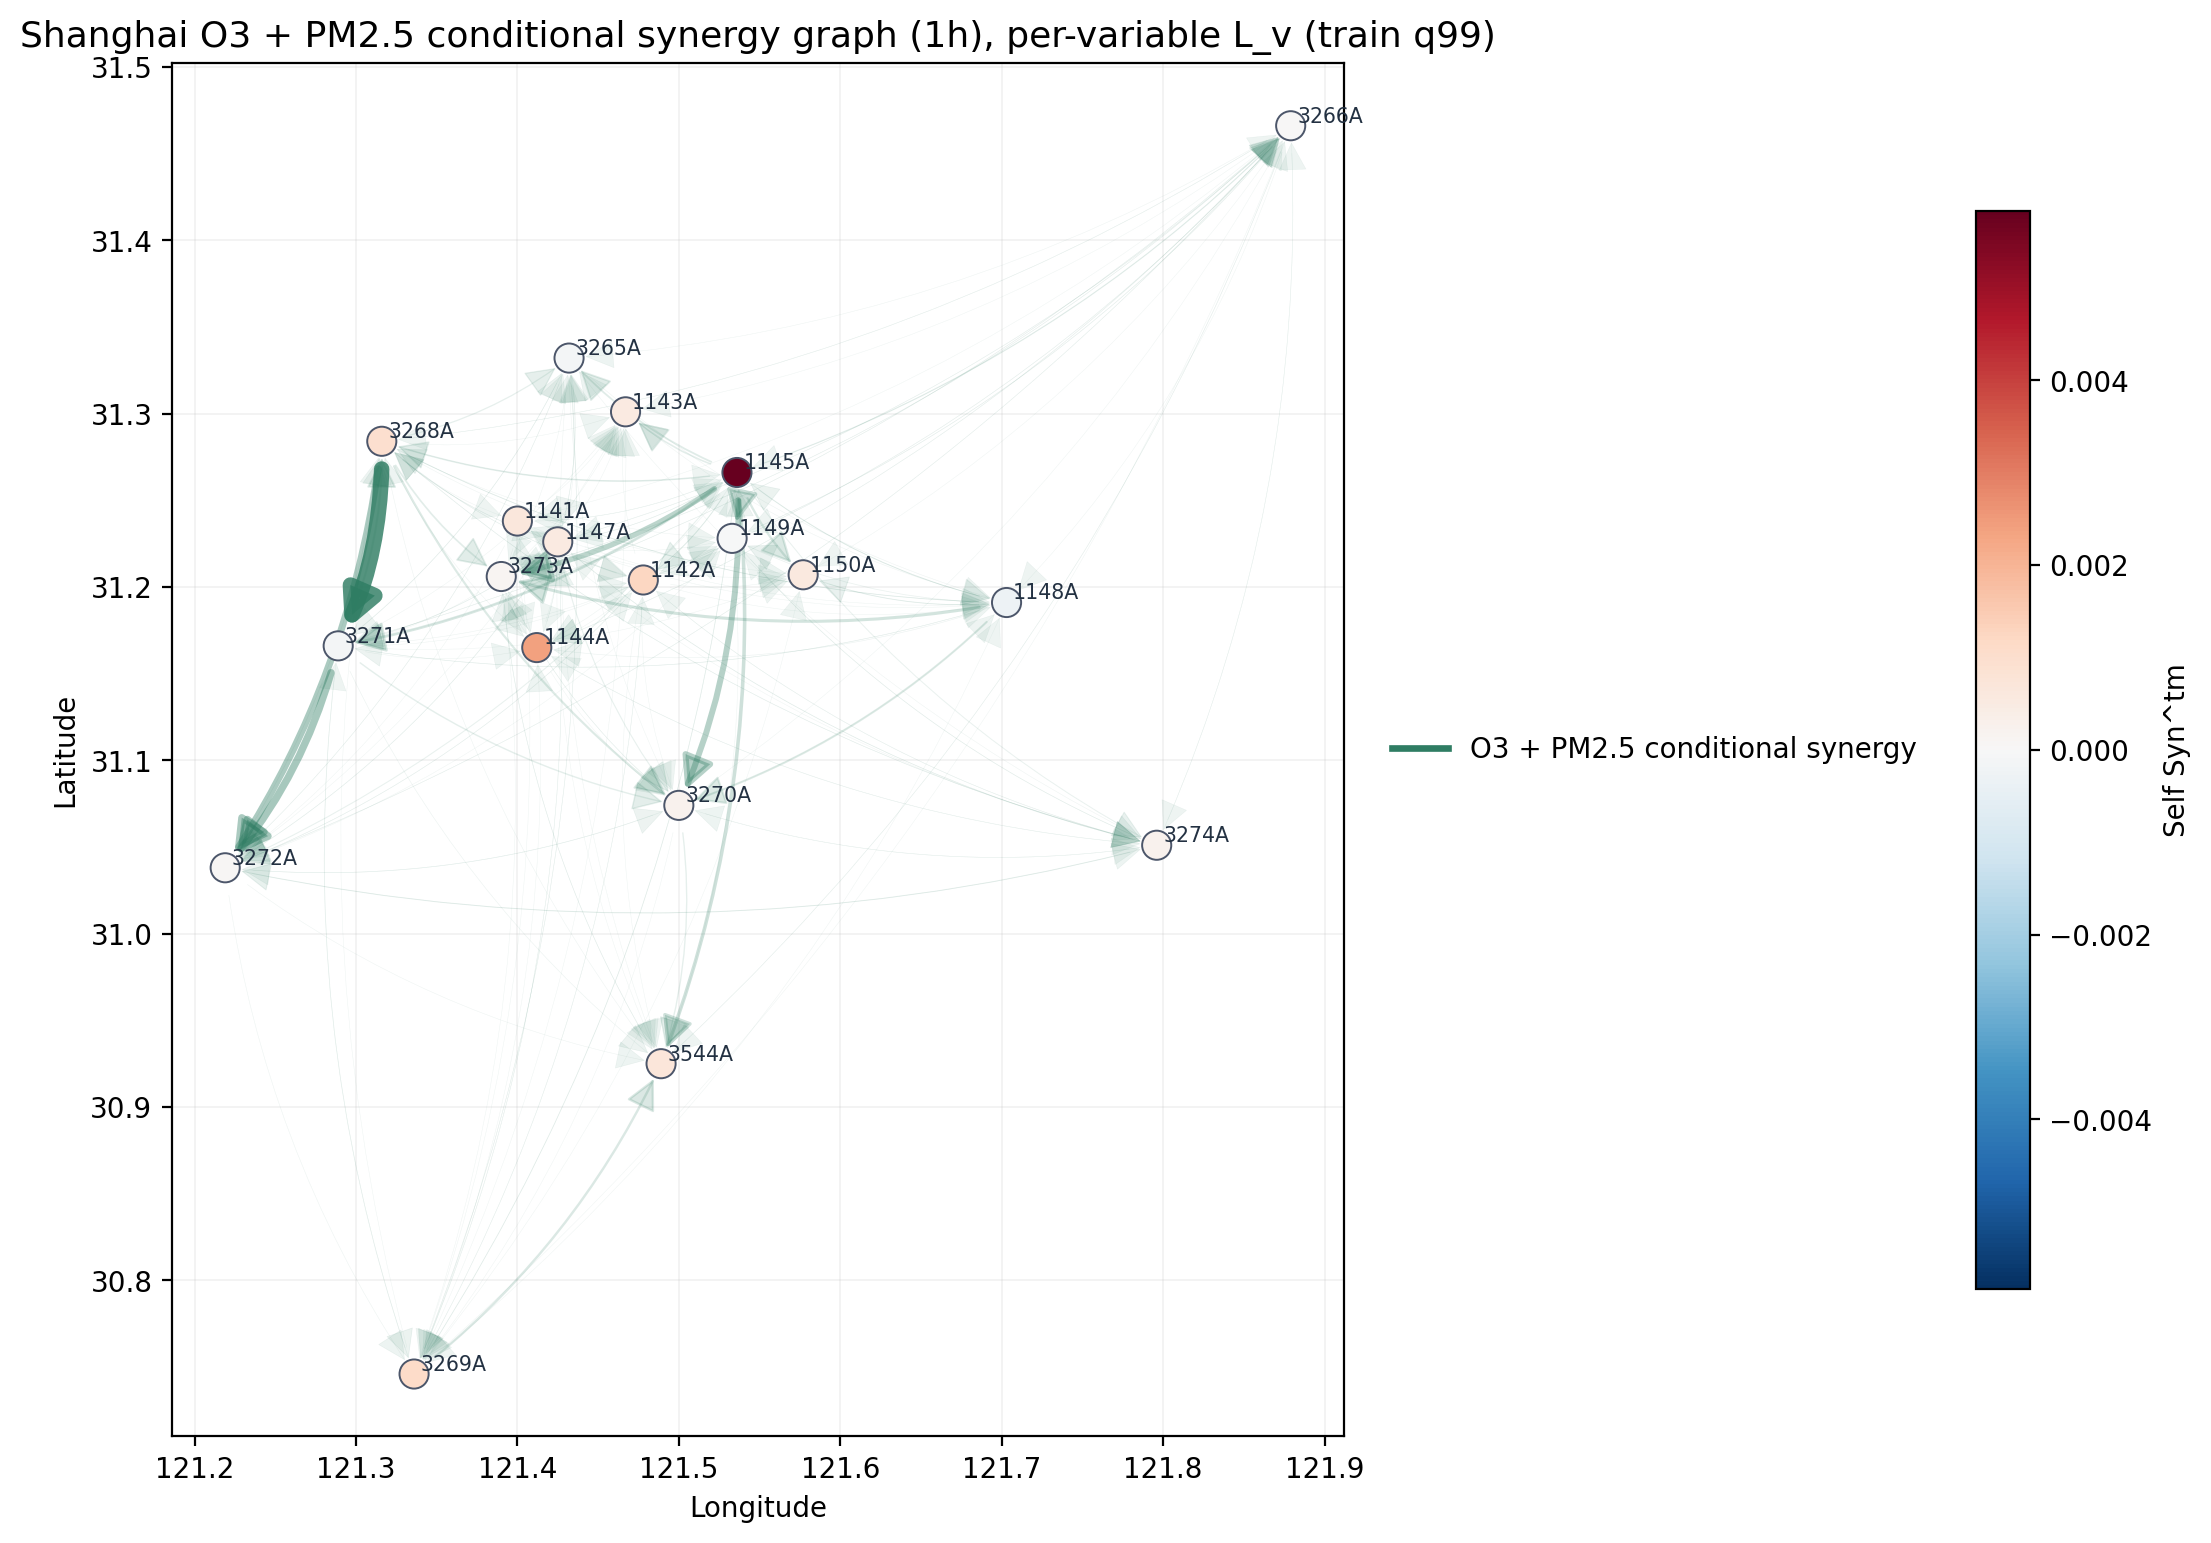

(   source_station_id target_station_id      mean  normalized_strength  \
 0              3265A             3268A  0.075912             1.000000   
 1              3271A             3272A  0.055234             0.727600   
 2              3544A             3270A  0.053141             0.700030   
 3              3268A             3265A  0.049764             0.655553   
 4              3273A             3271A  0.045299             0.596727   
 5              3268A             3271A  0.044772             0.589790   
 6              3269A             3544A  0.039669             0.522563   
 7              3271A             3268A  0.039264             0.517225   
 8              3271A             3273A  0.032454             0.427517   
 9              1143A             3273A  0.031995             0.421475   
 10             3544A             3272A  0.031058             0.409128   
 11             3272A             3271A  0.029973             0.394839   
 12             1143A             3265

In [7]:
causal_bundle = compute_station_causal_graph_results(
    bundle,
    predictions,
    force_recompute=FORCE_RECOMPUTE_COUPLING,
    coupling_method=CAUSAL_GRAPH_METHOD,
)
def summarize_negative_magnitudes(values: list[float]) -> dict[str, float]:
    negatives = sorted(abs(float(value)) for value in values if float(value) < 0)
    if not negatives:
        return {
            "count": 0,
            "min_abs": 0.0,
            "median_abs": 0.0,
            "p90_abs": 0.0,
            "max_abs": 0.0,
        }
    def quantile(level: float) -> float:
        if len(negatives) == 1:
            return float(negatives[0])
        index = (len(negatives) - 1) * float(level)
        lower = int(index)
        upper = min(lower + 1, len(negatives) - 1)
        weight = index - lower
        return float(negatives[lower] * (1.0 - weight) + negatives[upper] * weight)
    return {
        "count": int(len(negatives)),
        "min_abs": float(negatives[0]),
        "median_abs": quantile(0.5),
        "p90_abs": quantile(0.9),
        "max_abs": float(negatives[-1]),
    }
pairwise_display_1h = causal_bundle["pairwise_display_1h"]
pairwise_render_edges_1h = causal_bundle["pairwise_render_edges_1h"]
conditional_synergy_edges_df = causal_bundle["conditional_synergy_edges_df"]
conditional_synergy_edges_display_1h = causal_bundle["conditional_synergy_edges_display_1h"]
conditional_synergy_edges_global_ranked_1h = causal_bundle["conditional_synergy_edges_global_ranked_1h"]
pairwise_edges_1h = causal_bundle["global_coupling_summary_by_horizon"]["1h"]["pairwise_edges"]
negative_pairwise_values_1h = [float(row["mean"]) for row in pairwise_edges_1h if float(row["mean"]) < 0]
negative_conditional_synergy_values_1h = [
    float(value) for value in conditional_synergy_edges_df.loc[conditional_synergy_edges_df["mean"] < 0, "mean"].tolist()
]
negative_pairwise_edge_distribution_1h = summarize_negative_magnitudes(negative_pairwise_values_1h)
negative_conditional_synergy_edge_distribution_1h = summarize_negative_magnitudes(negative_conditional_synergy_values_1h)
negative_pairwise_edge_count_1h = int(negative_pairwise_edge_distribution_1h["count"])
negative_conditional_synergy_edge_count_1h = int(negative_conditional_synergy_edge_distribution_1h["count"])

display(Image(filename=str(artifact_paths["global_graph_1h"])))
display(Image(filename=str(artifact_paths["conditional_synergy_graph_1h"])))
negative_edge_summary_1h = {
    "pairwise": negative_pairwise_edge_distribution_1h,
    "conditional_synergy": negative_conditional_synergy_edge_distribution_1h,
}
(
    pairwise_render_edges_1h[["source_station_id", "target_station_id", "mean", "normalized_strength", "linewidth", "alpha"]]
    .sort_values("mean", ascending=False)
    .reset_index(drop=True)
    .head(20),
    conditional_synergy_edges_global_ranked_1h.head(10),
    negative_edge_summary_1h,
)


In [5]:
strongest_pairwise_edge = pairwise_display_1h.sort_values("mean", ascending=False).iloc[0]
strongest_synergy_edge = conditional_synergy_edges_display_1h.sort_values("mean", ascending=False).iloc[0]
final_conclusion_text = "\n".join([
    "本 notebook 在上海一步联合预测主线上，把因果图边权切换为 transport map 概率密度估计得到的 TM 版本。",
    f"当前采用搜索实验的最佳配置：{CAUSAL_GRAPH_L_PROFILE_NAME}，M={EFFECTIVE_CAUSAL_GRAPH_COUPLING_SAMPLE_COUNT}。",
    f"当前干预采样不再使用单个标量 L，而是按变量设置 train-q99 的 L_v；run_context 标签为 {run_context['causal_graph_box_label']}。",
    f"对 {', '.join(run_context['causal_graph_nonnegative_variables'])} 这些非负变量，采样时还会施加原始量纲下的 0 下界裁剪。",
    f"pairwise 图使用 O3 -> O3 的 EI^tm；当前最强显示边为 {strongest_pairwise_edge['source_station_id']} -> {strongest_pairwise_edge['target_station_id']}，平均强度为 {strongest_pairwise_edge['mean']:.3f}。",
    f"条件协同图使用 O3 + PM2.5 -> O3 的 Syn^tm；当前最强显示边为 {strongest_synergy_edge['source_station_id']} -> {strongest_synergy_edge['target_station_id']}，平均协同强度为 {strongest_synergy_edge['mean']:.3f}。",
    f"当前图上展示的不是所有因果边，而是筛选后的显示子集：pairwise 图先去掉自环和非正边，再按 CAUSAL_GRAPH_EDGE_KEEP_FRACTION={CAUSAL_GRAPH_EDGE_KEEP_FRACTION} 保留显示候选；conditional synergy 图还会额外限制为每个目标站点最多 {run_context['graph_edges_per_target']} 条正边。",
    f"当前 1h 全量 pairwise 边中，负值边共有 {negative_pairwise_edge_count_1h} 条；其负值绝对值最小 {negative_pairwise_edge_distribution_1h['min_abs']:.6f}，中位数 {negative_pairwise_edge_distribution_1h['median_abs']:.6f}，p90 {negative_pairwise_edge_distribution_1h['p90_abs']:.6f}，绝对值最大 {negative_pairwise_edge_distribution_1h['max_abs']:.6f}。",
    f"当前 1h 全量 conditional synergy 边中，负值边共有 {negative_conditional_synergy_edge_count_1h} 条；其负值绝对值最小 {negative_conditional_synergy_edge_distribution_1h['min_abs']:.6f}，中位数 {negative_conditional_synergy_edge_distribution_1h['median_abs']:.6f}，p90 {negative_conditional_synergy_edge_distribution_1h['p90_abs']:.6f}，绝对值最大 {negative_conditional_synergy_edge_distribution_1h['max_abs']:.6f}。",
])
print(final_conclusion_text)
final_conclusion_text


本 notebook 在上海一步联合预测主线上，把因果图边权切换为 transport map 概率密度估计得到的 TM 版本。
当前采用搜索实验的最佳配置：L_profile_pollutant_x1.2，M=8192。
当前干预采样不再使用单个标量 L，而是按变量设置 train-q99 的 L_v；run_context 标签为 per-variable L_v (train q99)。
对 O3, PM2.5, t2m, d2m, sp, tp, blh, msdwswrf 这些非负变量，采样时还会施加原始量纲下的 0 下界裁剪。
pairwise 图使用 O3 -> O3 的 EI^tm；当前最强显示边为 3265A -> 3268A，平均强度为 0.076。
条件协同图使用 O3 + PM2.5 -> O3 的 Syn^tm；当前最强显示边为 3268A -> 3271A，平均协同强度为 0.001。
当前图上展示的不是所有因果边，而是筛选后的显示子集：pairwise 图先去掉自环和非正边，再按 CAUSAL_GRAPH_EDGE_KEEP_FRACTION=1 保留显示候选；conditional synergy 图还会额外限制为每个目标站点最多 2 条正边。
当前 1h 全量 pairwise 边中，负值边共有 25 条；其负值绝对值最小 0.000001，中位数 0.000048，p90 0.000060，绝对值最大 0.000061。
当前 1h 全量 conditional synergy 边中，负值边共有 162 条；其负值绝对值最小 0.000000，中位数 0.000008，p90 0.000111，绝对值最大 0.000313。


'本 notebook 在上海一步联合预测主线上，把因果图边权切换为 transport map 概率密度估计得到的 TM 版本。\n当前采用搜索实验的最佳配置：L_profile_pollutant_x1.2，M=8192。\n当前干预采样不再使用单个标量 L，而是按变量设置 train-q99 的 L_v；run_context 标签为 per-variable L_v (train q99)。\n对 O3, PM2.5, t2m, d2m, sp, tp, blh, msdwswrf 这些非负变量，采样时还会施加原始量纲下的 0 下界裁剪。\npairwise 图使用 O3 -> O3 的 EI^tm；当前最强显示边为 3265A -> 3268A，平均强度为 0.076。\n条件协同图使用 O3 + PM2.5 -> O3 的 Syn^tm；当前最强显示边为 3268A -> 3271A，平均协同强度为 0.001。\n当前图上展示的不是所有因果边，而是筛选后的显示子集：pairwise 图先去掉自环和非正边，再按 CAUSAL_GRAPH_EDGE_KEEP_FRACTION=1 保留显示候选；conditional synergy 图还会额外限制为每个目标站点最多 2 条正边。\n当前 1h 全量 pairwise 边中，负值边共有 25 条；其负值绝对值最小 0.000001，中位数 0.000048，p90 0.000060，绝对值最大 0.000061。\n当前 1h 全量 conditional synergy 边中，负值边共有 162 条；其负值绝对值最小 0.000000，中位数 0.000008，p90 0.000111，绝对值最大 0.000313。'